0        0
1        0
2     4500
3     7384
4     1600
      ... 
95       0
96    2470
97    2314
98    4500
99       0
Name: 캠핑장 면적, Length: 100, dtype: int64


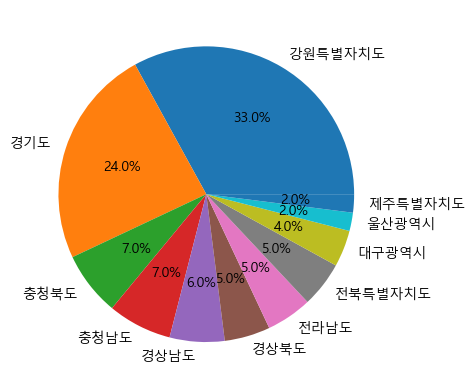

In [1]:
import pandas as pd
import requests
import matplotlib.pyplot as plt
import seaborn as sns

url = 'https://apis.data.go.kr/B551011/GoCamping/basedList'
params = {
    'serviceKey' : '6114f483bd6368bb21a7995881e36487d6baeae732d0dcdd3c719842dd0d35ed',
    'numOfRows' : '100',
    'pageNo' : '1',
    'MobileOS' : 'ETC',      # 필수: 기타 OS
    'MobileApp' : 'AppTest',  # 필수: 테스트 앱 이름
    '_type' : 'json'         # JSON 형식으로 받기
}
response = requests.get(url, params=params)
response
# JSON 데이터에서 데이터프레임으로 변환하는 경로
# (서버 응답 구조에 따라 ['response']['body']['items']['item'] 확인 필요)
data = response.json()
data
items = data['response']['body']['items']['item']
df = pd.DataFrame(items)
df.head()
region_counts = df['doNm'].value_counts()
region_counts
plt.rc('font', family='Malgun Gothic')
plt.pie(region_counts,
        labels=region_counts.index,
        autopct='%1.1f%%')           # 비율 표시 (소수점 첫째자리까지)
plt.show
df['allar'].dtypes #🟢면적 열 1️⃣타입확인! 숫자로 변환
df['캠핑장 면적'] = pd.to_numeric(df['allar'], errors='coerce').fillna(0)
print(df['캠핑장 면적'])

# df['sbrsCl'] #🟢부대시설 2️⃣
# df['부대시설개수'] = df['sbrsCl'].str.split(',').str.len()#.fillna(0)
# # df['부대시설개수'] 
# sns.scatterplot(data=df, x='캠핑장 면적', y='부대시설개수', hue='induty')
# plt.xlim(0, 30000)# x축 범위를 0부터 30,000까지만
# plt.legend(title='캠핑유형', fontsize=12, title_fontsize=13, loc='upper left', bbox_to_anchor=(1, 1))

In [2]:
#서울교통공사_역별승하차인원

import pandas as pd
import requests

# 1. API 접속 정보 설정
url = 'https://apis.data.go.kr/B553766/psgr/getStnPsgr'
params = {
    'serviceKey' : '6114f483bd6368bb21a7995881e36487d6baeae732d0dcdd3c719842dd0d35ed',
    'pageNo' : '1',  # 가져올 데이터 개수
    'numOfRows' : '10',      # 결과 형식을 JSON으로 지정 (가장 다루기 편함)
    '_type' : 'json'     # 대전광역시 예시
}

response = requests.get(url, params=params)
response
# 1. 응답 상태 코드 확인 (200이 나와야 정상)
print(response.status_code)
# 2. 내용물을 날것(텍스트)으로 출력해보기
print(response.text) 

# 3. JSON 데이터를 데이터프레임으로 변환
# 데이터의 계층 구조에 따라 ['response']['body']['items']['item'] 경로는 달라질 수 있습니다.
# data = response.json()
# data
# items = data['response']['body']['items']['item']
# df = pd.DataFrame(items)

# print("--- API 데이터 호출 완료 ---")
# print(df[['routeNm', 'startNodeNm', 'endNodeNm']].head()) # 노선명, 기점, 종점 확인

200
<?xml version='1.0' encoding='UTF-8'?><response><header><resultCode>97</resultCode><resultMsg>CLIENT_ERROR</resultMsg></header><body><items/><pageNo/><numOfRows/><totalCount/></body></response>


[사전 준비]

공공데이터포털 접속 및 로그인
🍋'국토교통부_버스노선정보' 또는 '서울특별시_정류소정보' 활용 신청 (즉시 승인)
일반 인증키(Encoding/Decoding) 복사